### Query

In [3]:
import io, time
import os
import numpy as np, pandas as pd, requests
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

ZTF_URL    = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves"

## 0. Querrying ZTF Lightcurves

Requesting at least 50 epochs per band in all 3 ZTF bands, taking a sample of 150 SDSS quasar lightcurves

In [4]:
z_max = 0.5
min_epochs = 50
num_obj = 150
BAD_MASK = 32768  
r_deg = 3.0 / 3600

curves = Path("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/lightcurves/ztf_sample.pkl")

if curves.exists():
    with open(curves, "rb") as f:
        sample = pickle.load(f)
    print(f"resumed from checkpoint: {len(sample)} objects already fetched")
else:
    sample = {}

resumed from checkpoint: 150 objects already fetched


In [1]:
#from astroquery.sdss import SDSS
#qsos = SDSS.query_sql(f"""
#    SELECT TOP {num_obj * 10} bestobjid, ra, dec, z FROM SpecObj
#    WHERE class='QSO' AND zWarning=0 AND z<{z_max} ORDER BY bestobjid
#""").to_pandas()

#qsos["bestobjid"] = qsos["bestobjid"].astype(str)   # string that avoids int overflow to 0
#print(f"{len(qsos)} candidate QSOs")
#qsos.head()

## 1. Cone search and retrival from ZTF

In [ ]:
i = 0
# print(i)
for i, row in qsos.iterrows():
    if i < 366:
        continue
    if len(sample) >= num_obj:
        break
    if row.bestobjid in sample:
        print("object already in the sample")
        continue

    for attempt in range(2):
        try:
            text = requests.get(ZTF_URL, timeout=60, params={
            "POS":f"CIRCLE {row.ra} {row.dec} {r_deg}",
            "BAD_CATFLAGS_MASK": BAD_MASK, "FORMAT": "CSV"
            }).text
            df = pd.read_csv(io.StringIO(text))
            if "filtercode" in df.columns:
                break
        except Exception as e:
            print(f"  [{i+1}] attempt {attempt +1}: {type(e).__name__}")
            pass
        time.sleep(7 * (attempt + 1))     # 5s, 10s, 15s backoff
    else:
        print(f"  [{i+1}] failed after retries") 
        continue
    #try:
    #    text = requests.get(ZTF_URL, timeout=60, params={
    #        "POS":f"CIRCLE {row.ra} {row.dec} {r_deg}",
    #        "BAD_CATFLAGS_MASK": BAD_MASK, "FORMAT": "CSV"
    #    }).text
    #    df = pd.read_csv(io.StringIO(text))

    #except Exception as e:
    #    print(f"  [{i+1}] {type(e).__name__}"); continue


    df["band"] = df["filtercode"].str[-1]
    lc = {}
    for b in ["g", "r", "i"]:
        sub = df[df.band == b]
        if len(sub):
            sub = sub[sub.oid == sub.oid.value_counts().idxmax()].sort_values("mjd")
            d = sub[["mjd", "mag", "magerr"]].reset_index(drop=True)
            keep = np.concatenate([[True], np.diff(d.mjd.values) > 0.3])   # same night dedup
            lc[b] = d[keep].reset_index(drop=True)

    ok = all(b in lc and len(lc[b]) >= min_epochs for b in ["g", "r", "i"])
    print(f"  [{i+1}] { {b: len(d) for b, d in lc.items()} }  {'KEEP' if ok else 'skip'}")
    if ok:
        sample[row.bestobjid] = {"lc": lc, "z": row.z}
        if len(sample) % 15 == 0:      # save every 15 curves
            with open(curves, "wb") as f:
                pickle.dump(sample, f)
            print(f"checkpoint saved: {len(sample)} objects")
    time.sleep(7)

with open(curves, "wb") as f:
    pickle.dump(sample, f)

# to refetch from other notebook: 
## with open("ztf_sample.pkl", "rb") as f:
## sample = pickle.load(f)

print(f"\n{len(sample)} good QSOs with >={min_epochs} epochs in g, r, i saved to {curves}")

0
  [367] {'g': 68, 'r': 350, 'i': 60}  KEEP
  [368] {'r': 39, 'i': 11}  skip
  [369] {'g': 237, 'r': 352, 'i': 60}  KEEP
  [370] {'g': 189, 'r': 209}  skip
  [371] {'g': 185, 'r': 306, 'i': 71}  KEEP
  [372] {'g': 8, 'r': 147, 'i': 41}  skip
  [373] {'g': 174, 'r': 301, 'i': 67}  KEEP
  [374] {'g': 94, 'r': 268, 'i': 69}  KEEP
  [375] {'g': 134, 'r': 280, 'i': 65}  KEEP
  [376] {'g': 237, 'r': 317, 'i': 68}  KEEP
  [377] {}  skip
  [378] {'g': 256, 'r': 286, 'i': 70}  KEEP
  [379] {'g': 254, 'r': 295, 'i': 69}  KEEP
  [380] {'g': 19, 'r': 169, 'i': 58}  skip
  [381] {'r': 51, 'i': 33}  skip
  [382] {'i': 66}  skip
  [383] {'g': 260, 'r': 301, 'i': 68}  KEEP
  [384] {'g': 231, 'r': 288, 'i': 65}  KEEP
  [385] {'g': 188, 'r': 277, 'i': 62}  KEEP
  [386] {'g': 266, 'r': 293, 'i': 67}  KEEP
  [387] {'g': 183, 'r': 259, 'i': 68}  KEEP
  [388] {}  skip
  [389] {'g': 240, 'r': 275, 'i': 69}  KEEP
checkpoint saved: 75 objects
  [390] {'g': 3, 'r': 89, 'i': 37}  skip
  [391] {'g': 131, 'r': 13

In [5]:
print(len(pickle.load(open(curves,"rb"))), "objects")

150 objects


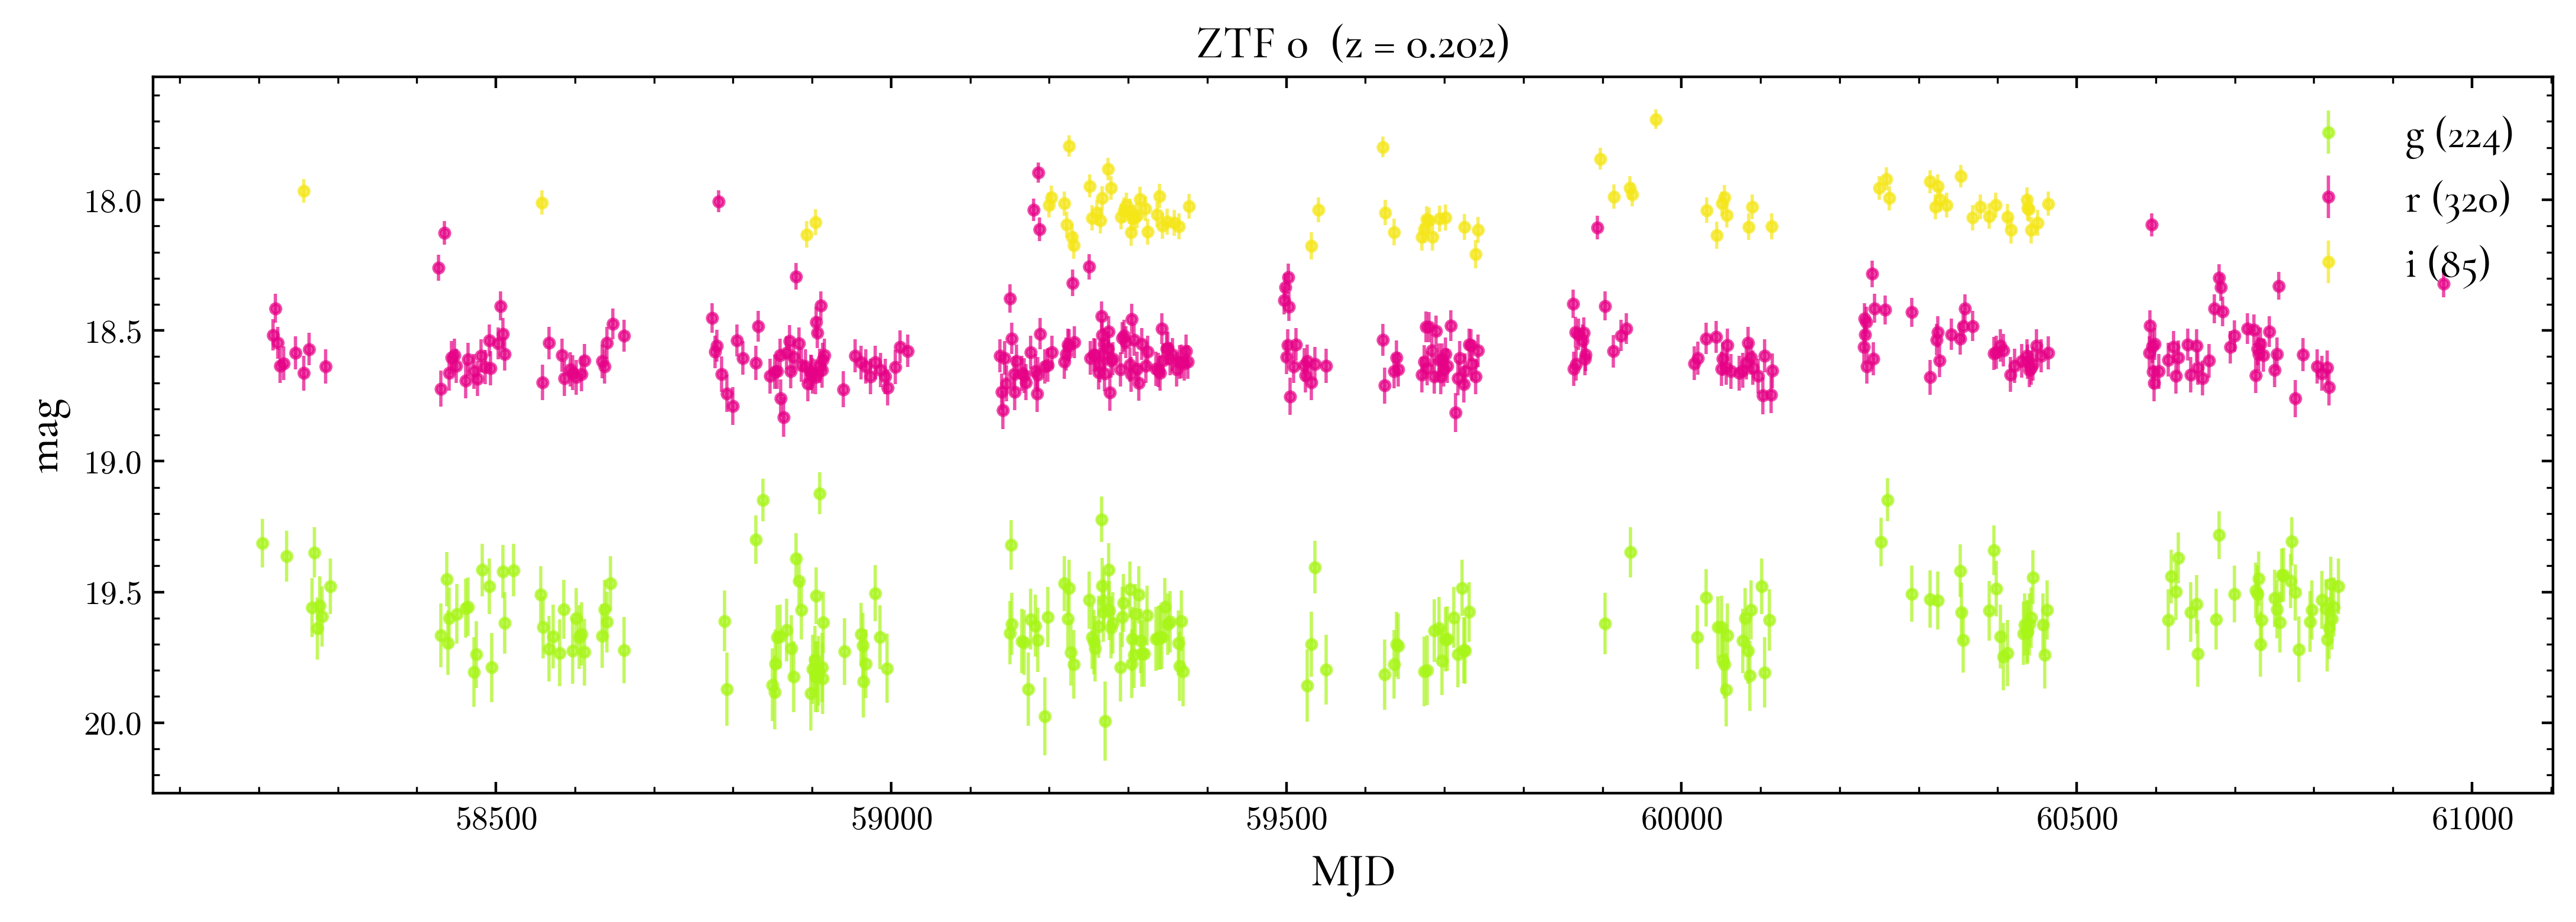

In [6]:
from Style import useAA
useAA()

oid = list(sample)[0]

col = {"g": "#a8f518", "r": "#e60287", "i": "#f5e618"}
plt.figure(figsize=(11, 4))
for b, d in sample[oid]["lc"].items():
    plt.errorbar(d.mjd, d.mag, d.magerr, fmt="o", ms=3, color=col[b],
                 alpha=0.7, capsize=0, label=f"{b} ({len(d)})")
plt.gca().invert_yaxis()
plt.xlabel("MJD", fontsize = 14); plt.ylabel("mag", fontsize = 14)
plt.legend(fontsize = 13)
plt.title(f"ZTF {oid}  (z = {sample[oid]['z']:.3f})", fontsize = 14)
plt.tight_layout()
plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/ZTF/ZTF_real_lc_example.pdf")
plt.show()


## 2. Saving the per-band statistics for the simulation

In [7]:
import json

# per-band stats
stats = {"n_objects": len(sample), "baseline_yr": None, "bands": {}}
base = [max(v["lc"][b].mjd.max() for b in v["lc"]) -
        min(v["lc"][b].mjd.min() for b in v["lc"]) for v in sample.values()]
stats["baseline_yr"] = float(np.median(base) / 365.25)
stats["provenance"] = {"min_epochs": min_epochs, "dedup_day": 0.3, "z_max": z_max}

for b in ["g", "r", "i"]:
    ep  = [len(v["lc"][b]) for v in sample.values()]
    dts = np.concatenate([np.diff(v["lc"][b].mjd.values) for v in sample.values()])
    err = np.concatenate([v["lc"][b].magerr.values for v in sample.values()])
    stats["bands"][b] = {
        "n_epochs_median": float(np.median(ep)),
        "n_epochs_range":  [float(np.percentile(ep, 16)), float(np.percentile(ep, 84))],
        "cadence_median_d": float(np.median(dts[dts > 0])),
        "magerr_median":   float(np.median(err)),
        "magerr_range":    [float(np.percentile(err, 16)), float(np.percentile(err, 84))],
    }

with open("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/lightcurves/ztf_stats.json", "w") as f:
    json.dump(stats, f, indent=2)
print(json.dumps(stats, indent=2))

{
  "n_objects": 150,
  "baseline_yr": 7.279610046543464,
  "bands": {
    "g": {
      "n_epochs_median": 234.0,
      "n_epochs_range": [
        170.2,
        283.0
      ],
      "cadence_median_d": 3.936840200003644,
      "magerr_median": 0.0730520785,
      "magerr_range": [
        0.035134443524,
        0.12763688724
      ]
    },
    "r": {
      "n_epochs_median": 279.0,
      "n_epochs_range": [
        225.84,
        327.64
      ],
      "cadence_median_d": 3.0396991000015987,
      "magerr_median": 0.0569304526,
      "magerr_range": [
        0.029360374100000003,
        0.09648070188
      ]
    },
    "i": {
      "n_epochs_median": 73.5,
      "n_epochs_range": [
        60.0,
        111.0
      ],
      "cadence_median_d": 6.003703650003445,
      "magerr_median": 0.0554164946,
      "magerr_range": [
        0.027941707436,
        0.09532965002
      ]
    }
  },
  "provenance": {
    "min_epochs": 50,
    "dedup_day": 0.3,
    "z_max": 0.5
  }
}


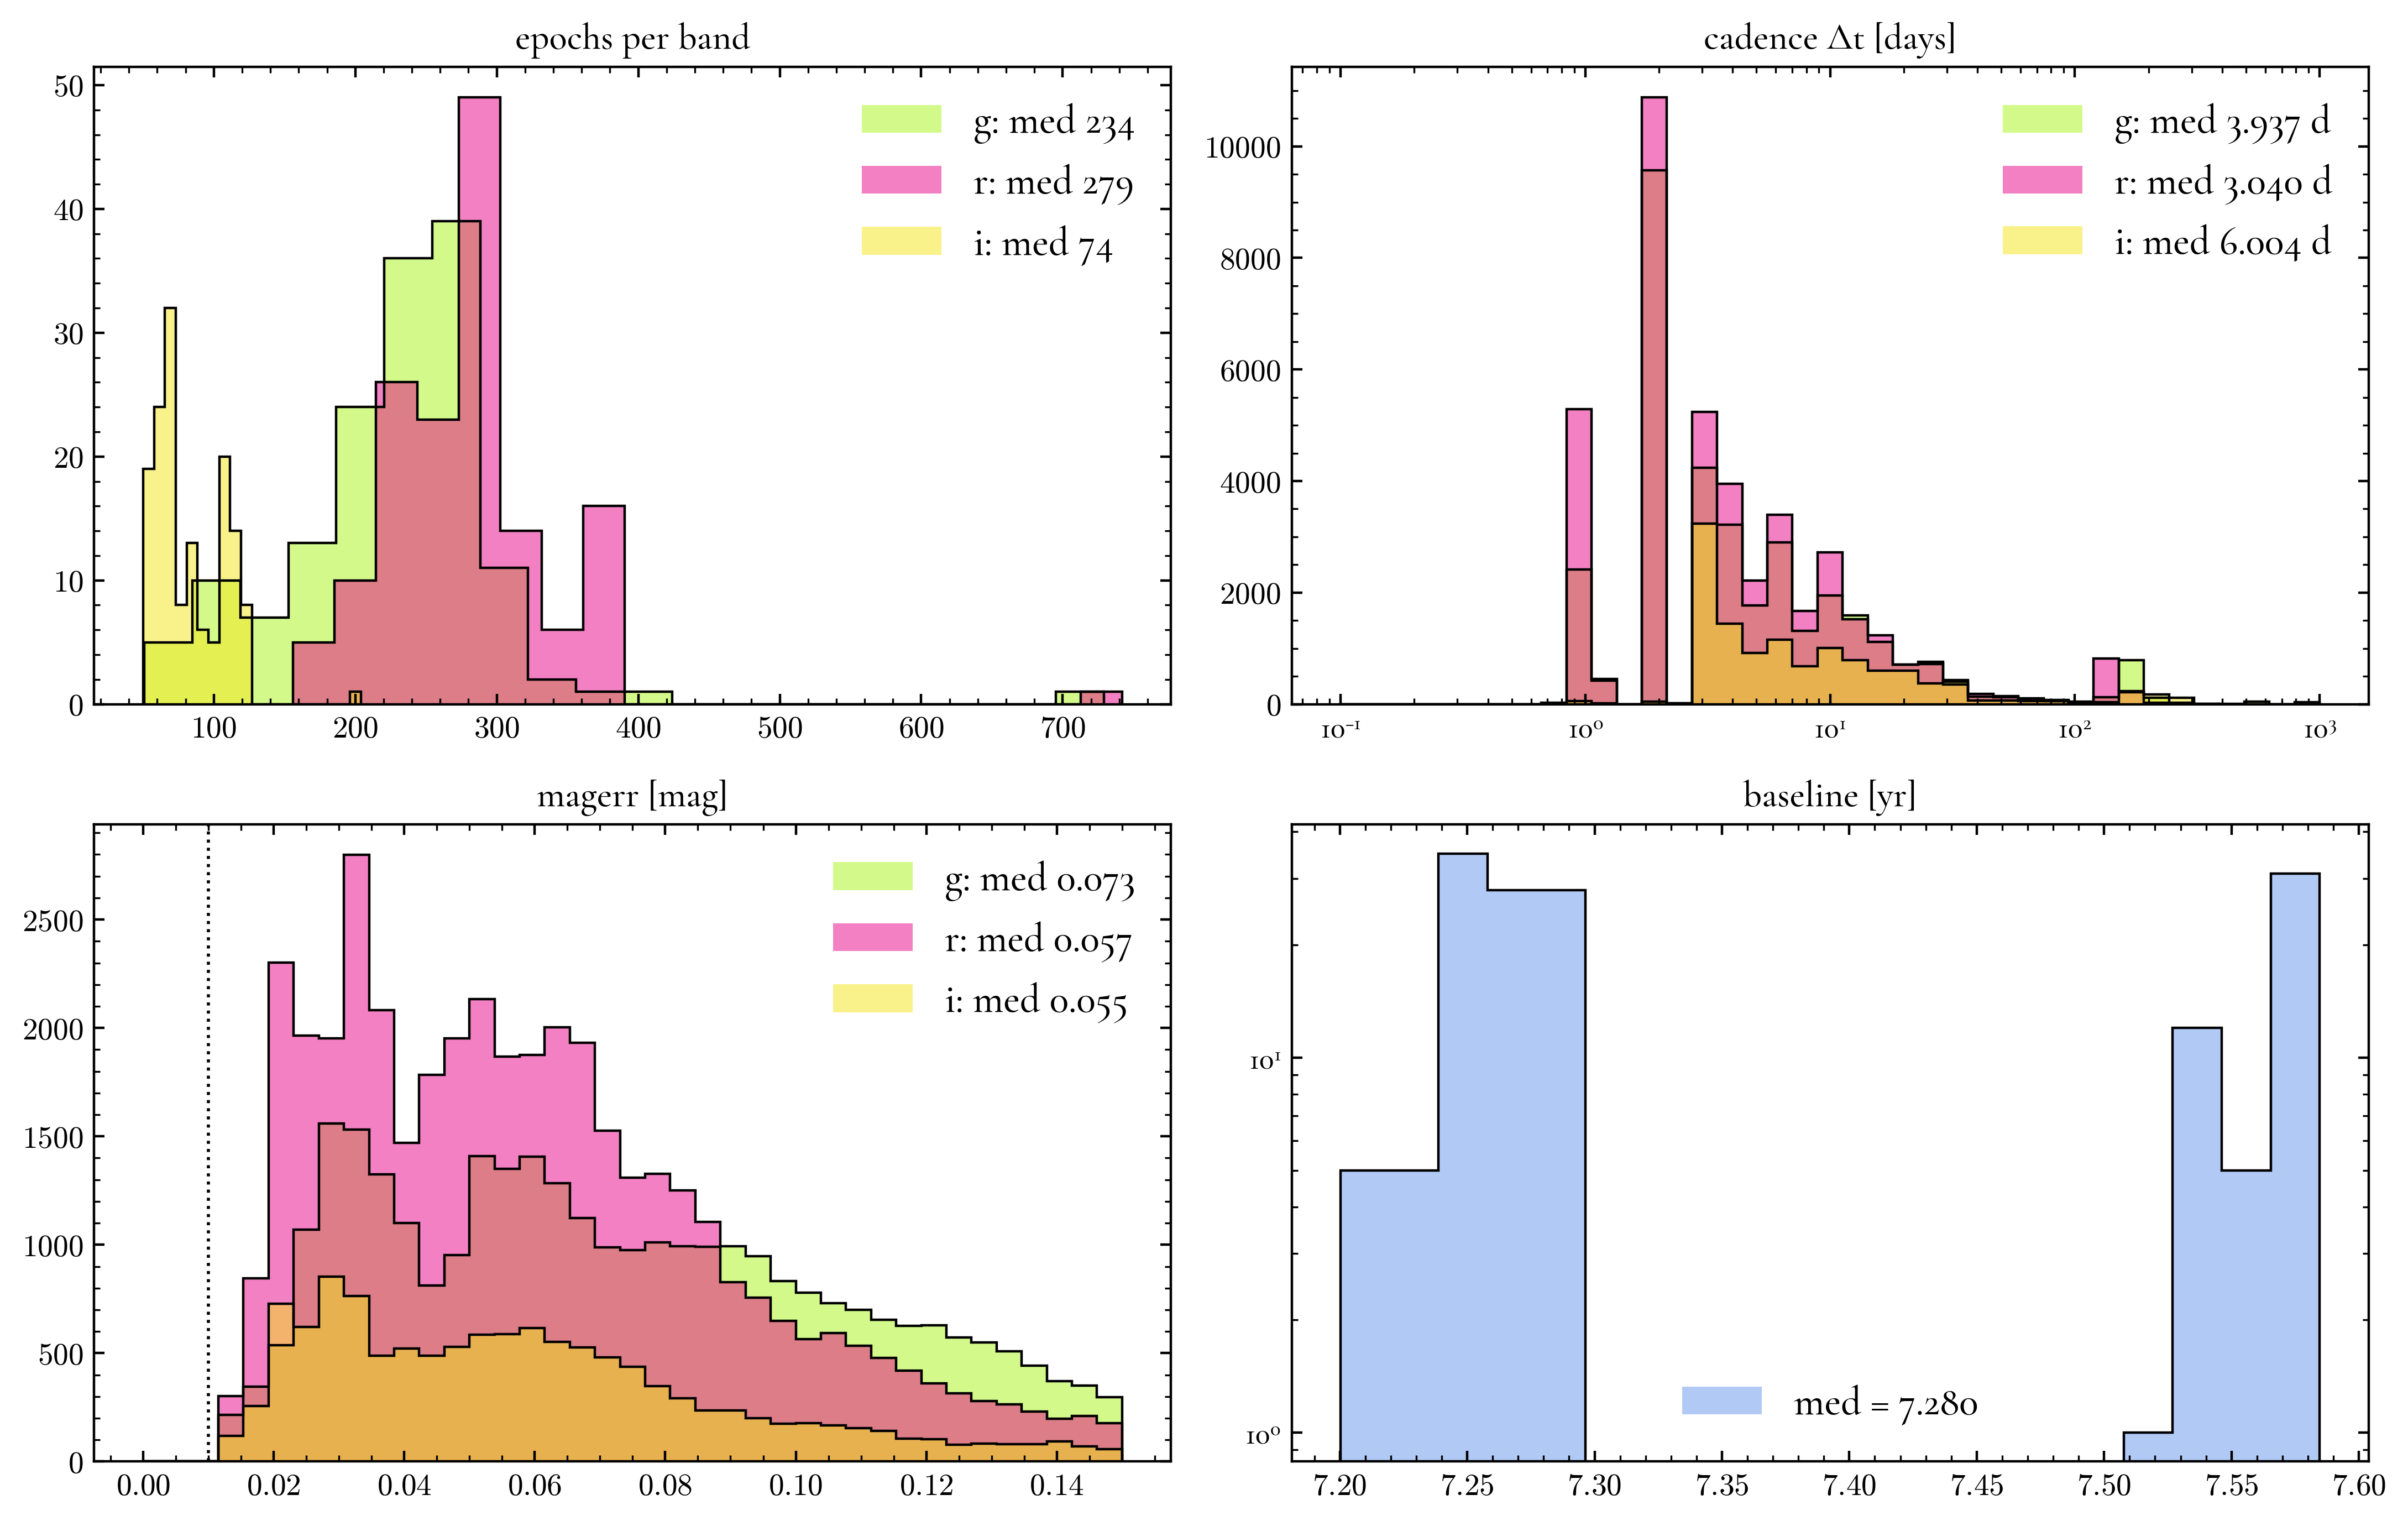

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

for b in ["g", "r", "i"]:
    ep  = [len(v["lc"][b]) for v in sample.values()]
    dts = np.concatenate([np.diff(v["lc"][b].mjd.values) for v in sample.values()])
    err = np.concatenate([v["lc"][b].magerr.values for v in sample.values()])

    ax[0,0].hist(ep, bins=20, histtype="stepfilled", color=col[b], alpha=0.5, 
                 edgecolor="none", label=f"{b}: med {np.median(ep):.0f}")
    ax[0,0].hist(ep, bins=20, histtype="step", lw=0.8, edgecolor="black")

    ax[0,1].hist(dts[dts > 0], bins=np.logspace(-1, 3, 40), histtype="stepfilled",
                 color=col[b], alpha=0.5, label=f"{b}: med {np.median(dts):.3f} d")
    ax[0,1].hist(dts[dts > 0], bins=np.logspace(-1, 3, 40), histtype="step", 
                 lw=0.8, edgecolor="black")

    ax[1,0].hist(err, bins=np.linspace(0, 0.15, 40), alpha=0.5, histtype="stepfilled",
                 color=col[b], label=f"{b}: med {np.median(err):.3f}")
    ax[1,0].hist(err, bins=np.linspace(0, 0.15, 40), histtype="step", 
                 lw=0.8, edgecolor="black")

base = [max(v["lc"][b].mjd.max() for b in v["lc"]) -
        min(v["lc"][b].mjd.min() for b in v["lc"]) for v in sample.values()]

ax[0,0].set_title("epochs per band");   ax[0,0].legend(fontsize=13)
ax[0,1].set_title("cadence Δt [days]"); ax[0,1].set_xscale("log"); ax[0,1].legend(fontsize=13)
ax[1,0].set_title("magerr [mag]");      ax[1,0].axvline(0.01, color="k", ls=":")
ax[1,0].legend(fontsize=13)
ax[1,1].set_title("baseline [yr]")     
ax[1,1].hist(np.array(base)/365.25, histtype="stepfilled", bins=20, color="cornflowerblue",
             alpha = 0.5, label=f"med = {np.median(np.array(base)/365.25):.3f}")
ax[1,1].hist(np.array(base)/365.25, histtype="step", bins=20, lw=0.8, edgecolor="black")
ax[1,1].legend(fontsize=13)
ax[1,1].set_yscale("log")

plt.tight_layout()
plt.savefig("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/ZTF/ZTF_statistics.pdf")
plt.show()

In [9]:
print((np.min([np.min(np.diff(np.sort(v["lc"]["r"].mjd.values))) for v in sample.values()])), "d")
print((np.min([np.min(np.diff(np.sort(v["lc"]["g"].mjd.values))) for v in sample.values()])), "d")
print((np.min([np.min(np.diff(np.sort(v["lc"]["i"].mjd.values))) for v in sample.values()])), "d")

0.7887730999937048 d
0.7251040999981342 d
0.8381365000022925 d


Before checked the minimum separation between epochs and it indicated that some observations where only ~36s apart, making them perfectly correlated in a DRW process and effectively contributing nothing while altering the cadence statistics. 

 ``` 
print(24*60*60*(np.min([np.min(np.diff(np.sort(v["lc"]["r"].mjd.values))) for v in sample.values()])))
print(24*60*60*(np.min([np.min(np.diff(np.sort(v["lc"]["g"].mjd.values))) for v in sample.values()])))
print(24*60*60*(np.min([np.min(np.diff(np.sort(v["lc"]["i"].mjd.values))) for v in sample.values()])))

out: 39.00095962453633 s
     39.99456027522683 s
     98.9971200702712 s
```
Reason why we dropped "duplicates" that are less that ~1/3 of a day appart, now they check out

## 3. Simulating the data set

In [10]:
import importlib, LightCurves
importlib.reload(LightCurves)
from LightCurves import MultibandLCGenerator, makeDataset, saveDataset, plotLC

DATA = "/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/lightcurves/data"
os.makedirs(DATA, exist_ok=True)

In [11]:
# contains n_objects, baseline_yr, bands
with open("/Users/anacecilialr/GitHub/MASS/MASS-Thesis/experiments/lightcurves/ztf_stats.json") as f:
    ZTF = json.load(f)

print(ZTF["provenance"])
print(ZTF["baseline_yr"], "years")
BAND = "r"

# r-band: n_epochs_median, n_epochs_range, cadence_median_d, magerr_median, magerr_range


{'min_epochs': 50, 'dedup_day': 0.3, 'z_max': 0.5}
7.279610046543464 years


All 3 bands will have the same ~7.28 year baseline, but each will inherit the corresponding ZTF cadence (by resampling real observed times, thinned to 85-95% and jittered by ~0.5 day) and the photometric noise (per-epoch noise is drawn from the band's magnitude-error range). 
```
normalized yerr for band r: 0.26–0.86, median 0.48
normalized yerr for band i: 0.25–0.85, median 0.46
normalized yerr for band g: 0.31–1.14, median 0.60
```

In [12]:

MultibandLCGenerator.magerr_lo = ZTF["bands"][BAND]["magerr_range"][0]
MultibandLCGenerator.magerr_hi = ZTF["bands"][BAND]["magerr_range"][1]

train_c, val_c = makeDataset(
    n_curves=3000, val_frac=0.2, seed0=0,
    gen_kwargs=dict(bands=BAND, driver_band=BAND,
                    t_max=ZTF["baseline_yr"]*365.25, # in days
                    tau_driver=None, sigma_driver=0.112),   # fixed sigma atm
    lc_kwargs=dict(),
)

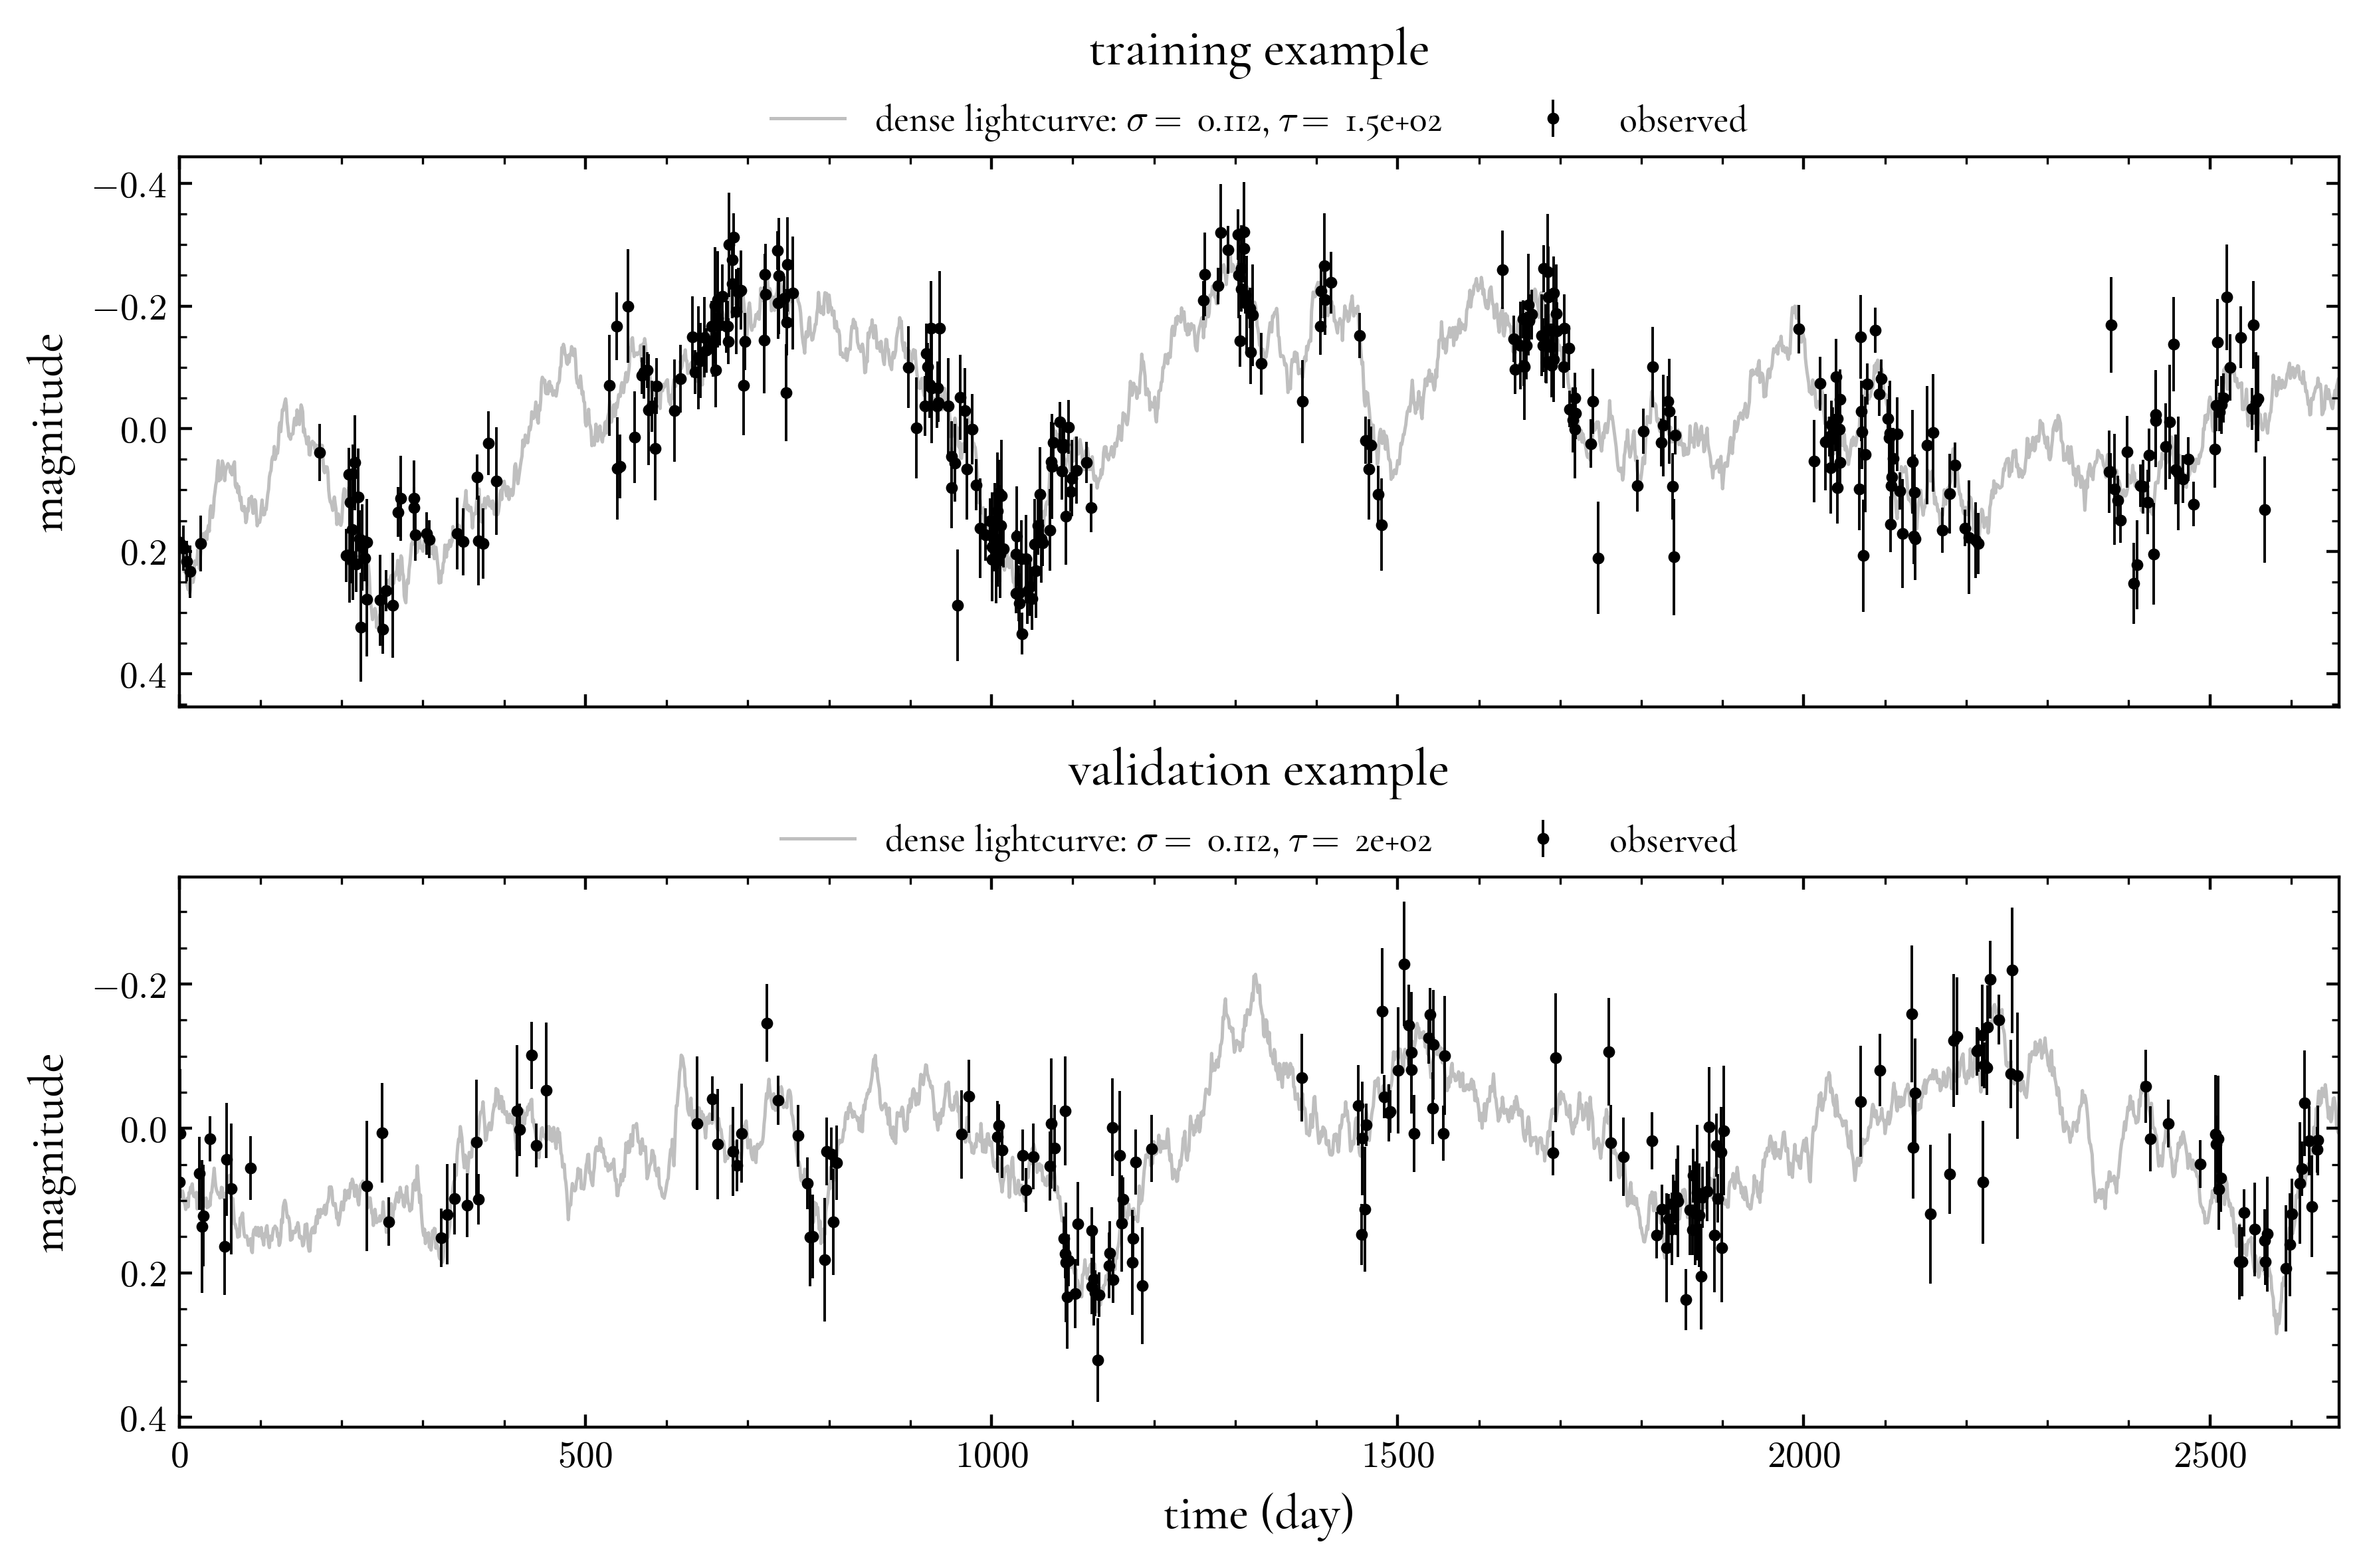

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)


plotLC(train_c[90], ax=axes[0])
plotLC(val_c[180],   ax=axes[1])
axes[0].set_title("training example", fontsize=14, pad=25)
axes[1].set_title("validation example", fontsize=14, pad=25)
axes[0].set_xlabel("")
plt.tight_layout()
plt.show()

In [14]:
def make_band_dataset(band, ZTF, n_curves=3000):
    lo, hi = ZTF["bands"][band]["magerr_range"]
    return makeDataset(
        n_curves=n_curves, val_frac=0.2, seed0=0,
        gen_kwargs=dict(bands=band, driver_band=band,
                        t_max=ZTF["baseline_yr"]*365.25,
                        tau_driver=None, sigma_driver=0.112,
                        magerr_lo=lo, magerr_hi=hi),  
        lc_kwargs=dict(),
    )

def plot_regime(train_c, band):
    dts  = np.concatenate([np.diff(c["t_obs"]) / c["tau"] for c in train_c])
    gaps = np.array([np.max(np.diff(c["t_obs"])) / c["tau"] for c in train_c])   

    fig, ax = plt.subplots(1, 2, figsize=(9, 3))
    for a, data, bins, colour, xlabel in [
        (ax[0], dts,  np.logspace(-3, 1, 60), "royalblue",
         r"$\Delta t/\tau$ between consecutive epochs"),
        (ax[1], gaps, np.logspace(-1.5, 1, 40), "darkorchid",
         r"largest gap per curve, $\Delta t/\tau$")]:
        a.hist(data, bins=bins, histtype="step", lw=0.8, edgecolor="black")
        a.hist(data, bins=bins, histtype="stepfilled", lw=0.8, edgecolor="none",
               facecolor=colour, alpha=0.2)
        a.set_xscale("log"); a.axvline(1.0, color="k", ls="-.", lw=1)
        a.set_xlabel(xlabel, fontsize=12); a.set_ylabel("count", fontsize=13)
    ax[0].set_yscale("log")
    ax[0].text(1.15, ax[0].get_ylim()[1]*0.5, r"$\Delta t=\tau$", fontsize=9)
    ax[1].text(0.5,  ax[1].get_ylim()[1]*0.9, r"$\Delta t=\tau$", fontsize=9)
    fig.suptitle(f"{band}-band regime", fontsize=13, y = 0.88, va = "bottom", ha = "center")
    plt.tight_layout()
    plt.savefig(f"/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/ZTF/simulation_{band}_regime.pdf")
    plt.show()

    print(f"[{band}] spacings: median {np.median(dts):.3f} tau, 99th {np.percentile(dts,99):.2f} tau")
    print(f"[{band}] largest gap/curve: {np.percentile(gaps,[5,50,95]).round(2)} tau  (5/50/95)")
    print(f"[{band}] spacings above 1 tau: {100*np.mean(dts>1):.1f}%   "
          f"curves whose largest gap > 1 tau: {100*np.mean(gaps>1):.0f}%")

### 3.1. Example curves and checking the regimes

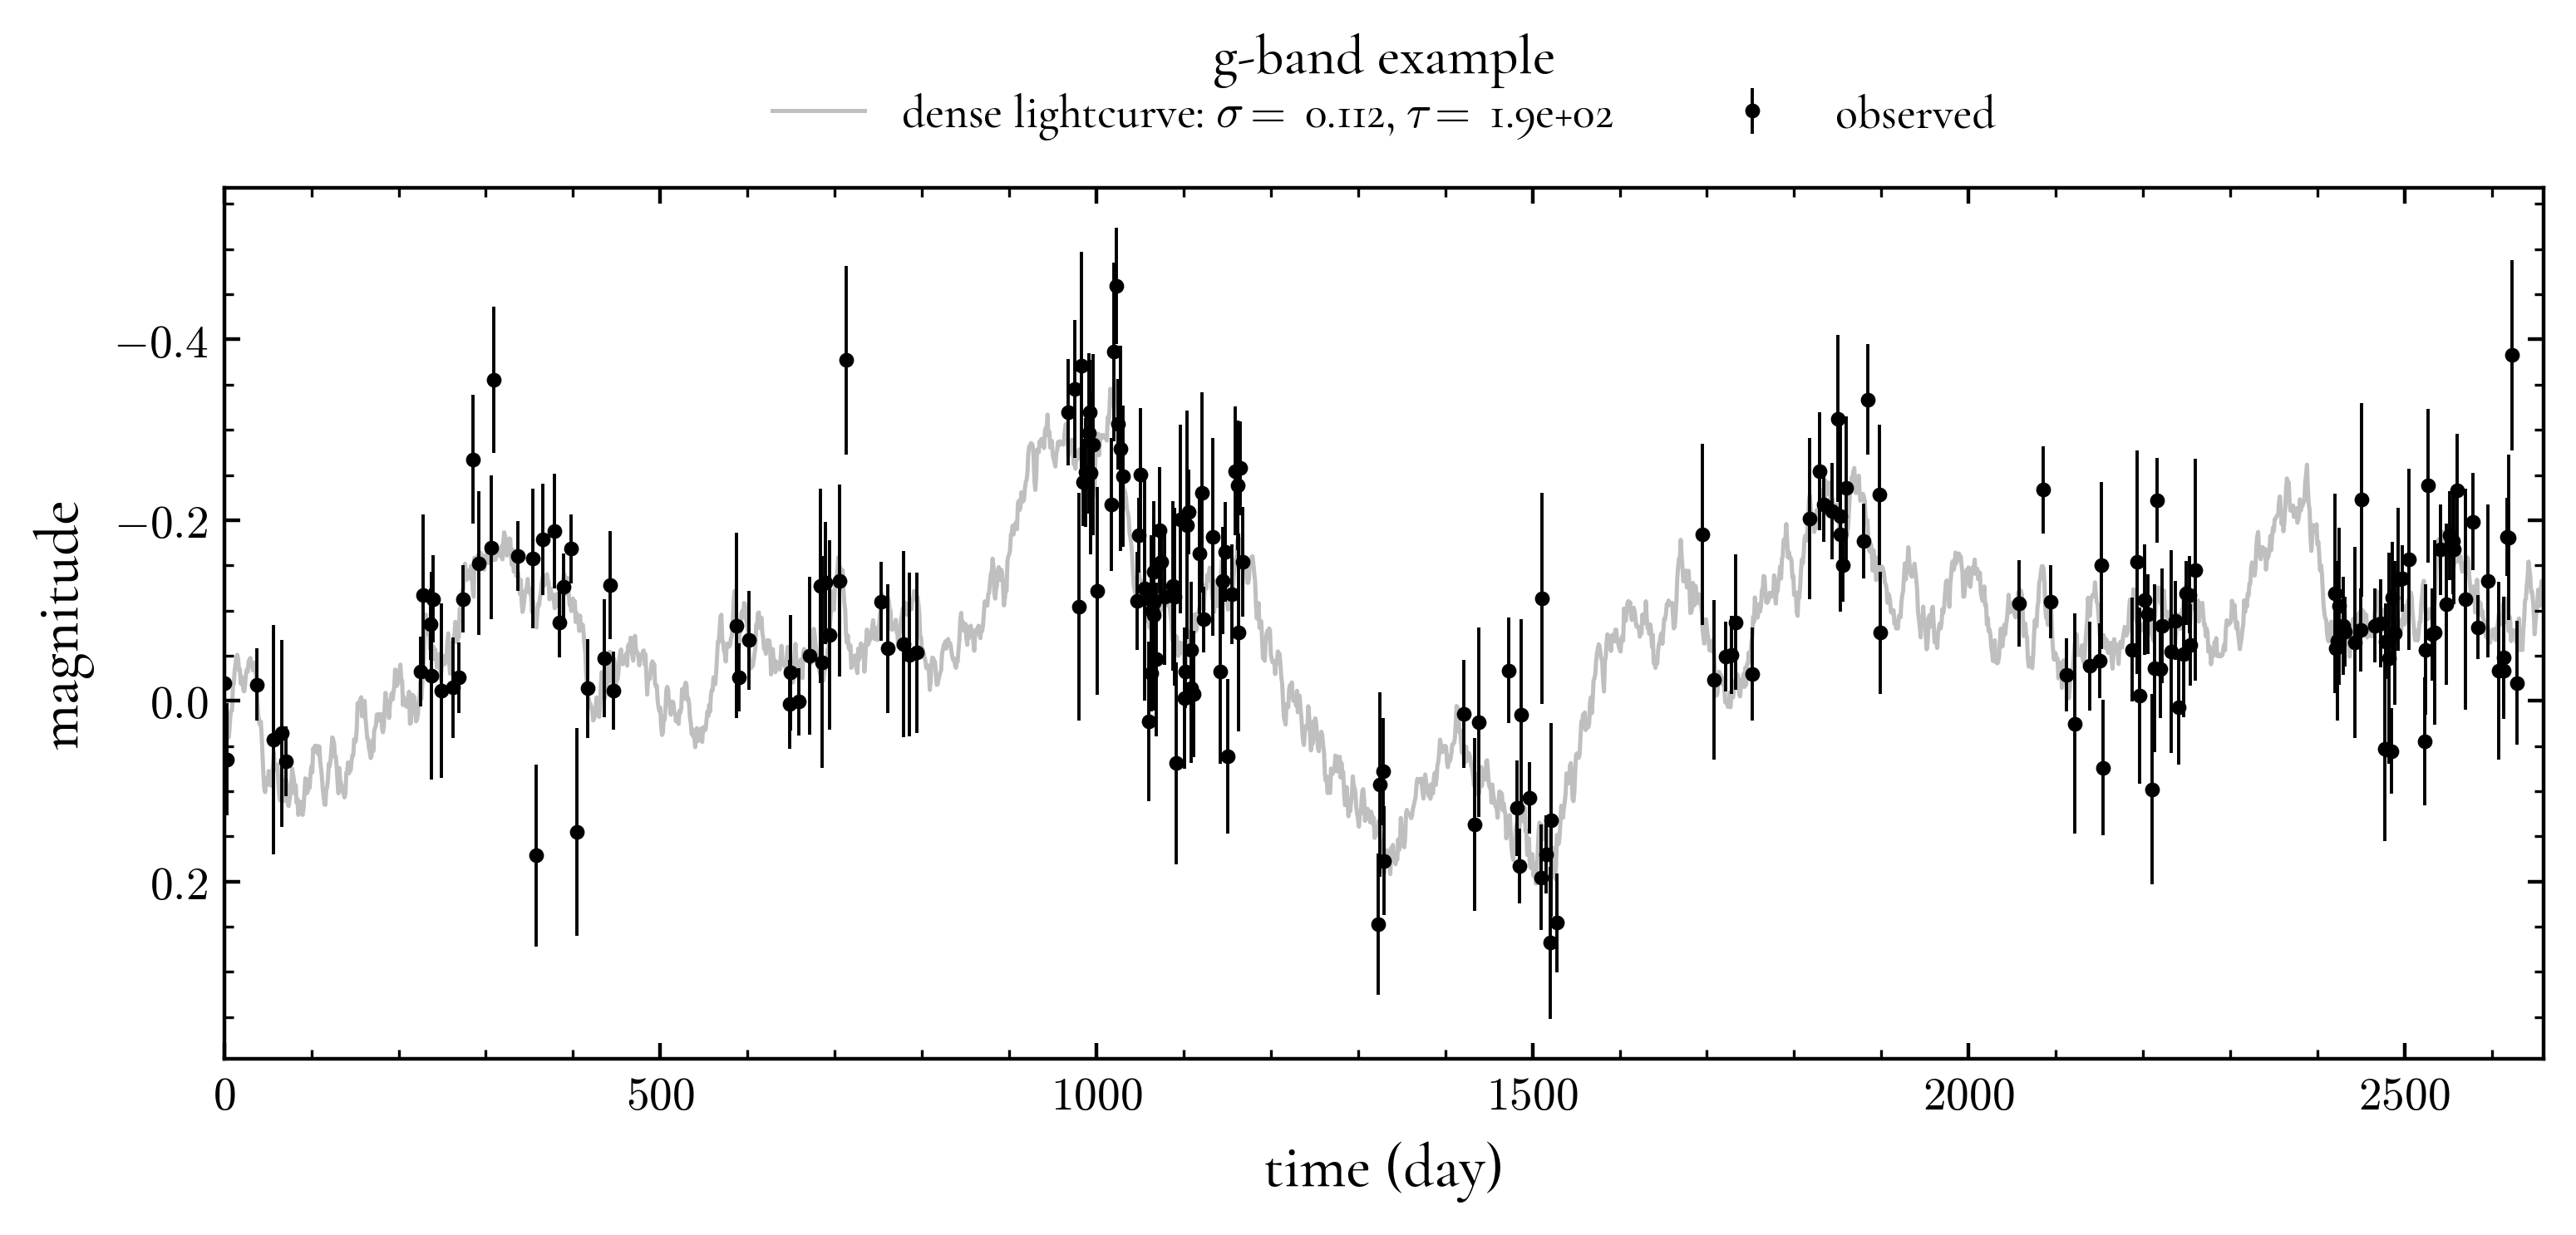

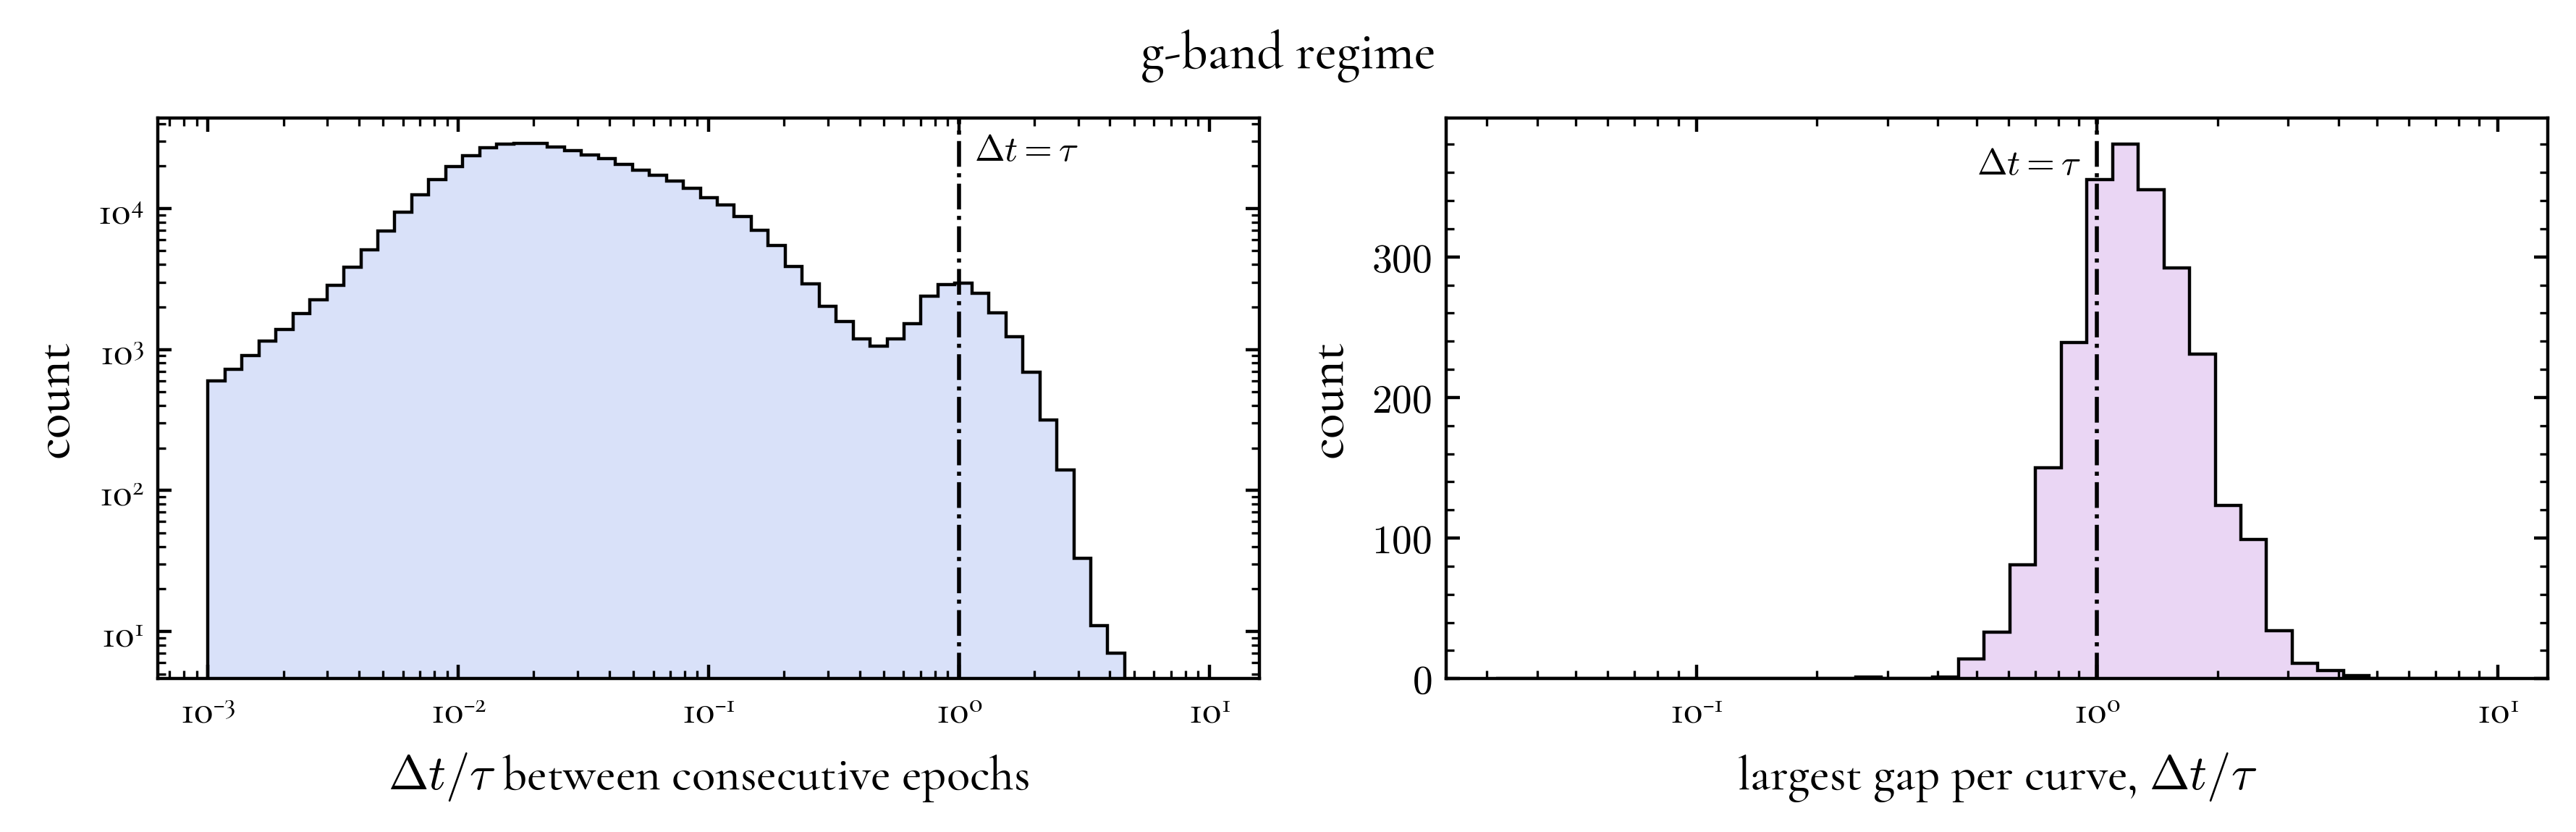

[g] spacings: median 0.025 tau, 99th 1.26 tau
[g] largest gap/curve: [0.69 1.24 2.39] tau  (5/50/95)
[g] spacings above 1 tau: 1.8%   curves whose largest gap > 1 tau: 73%
g: 2400+600 curves saved


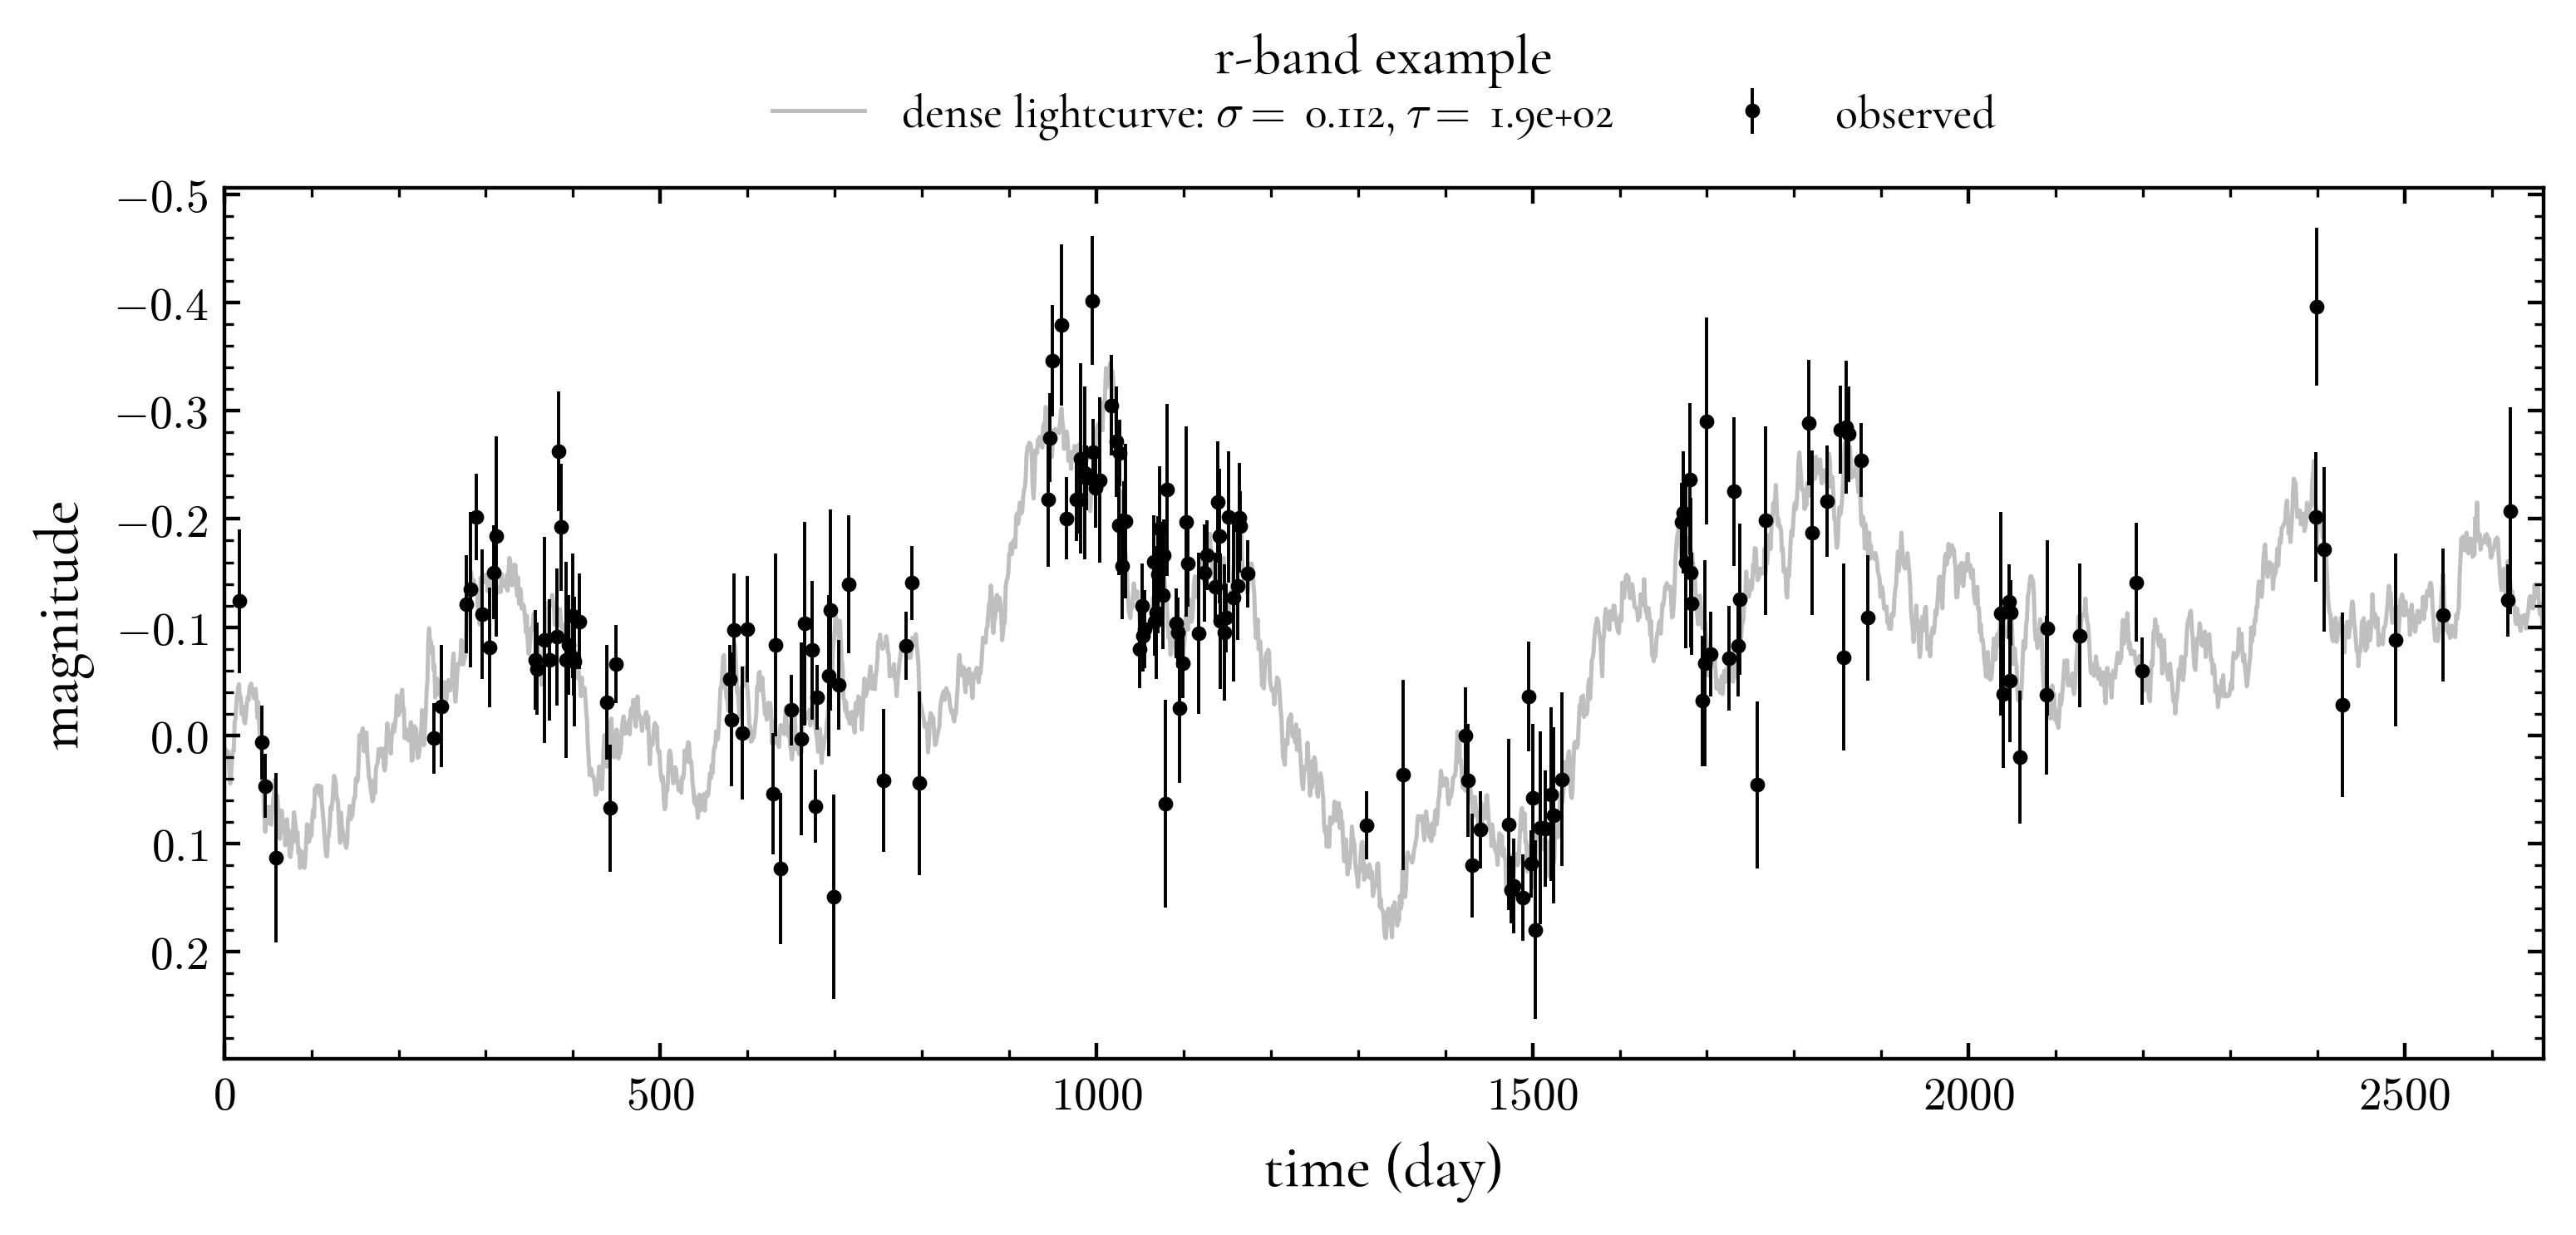

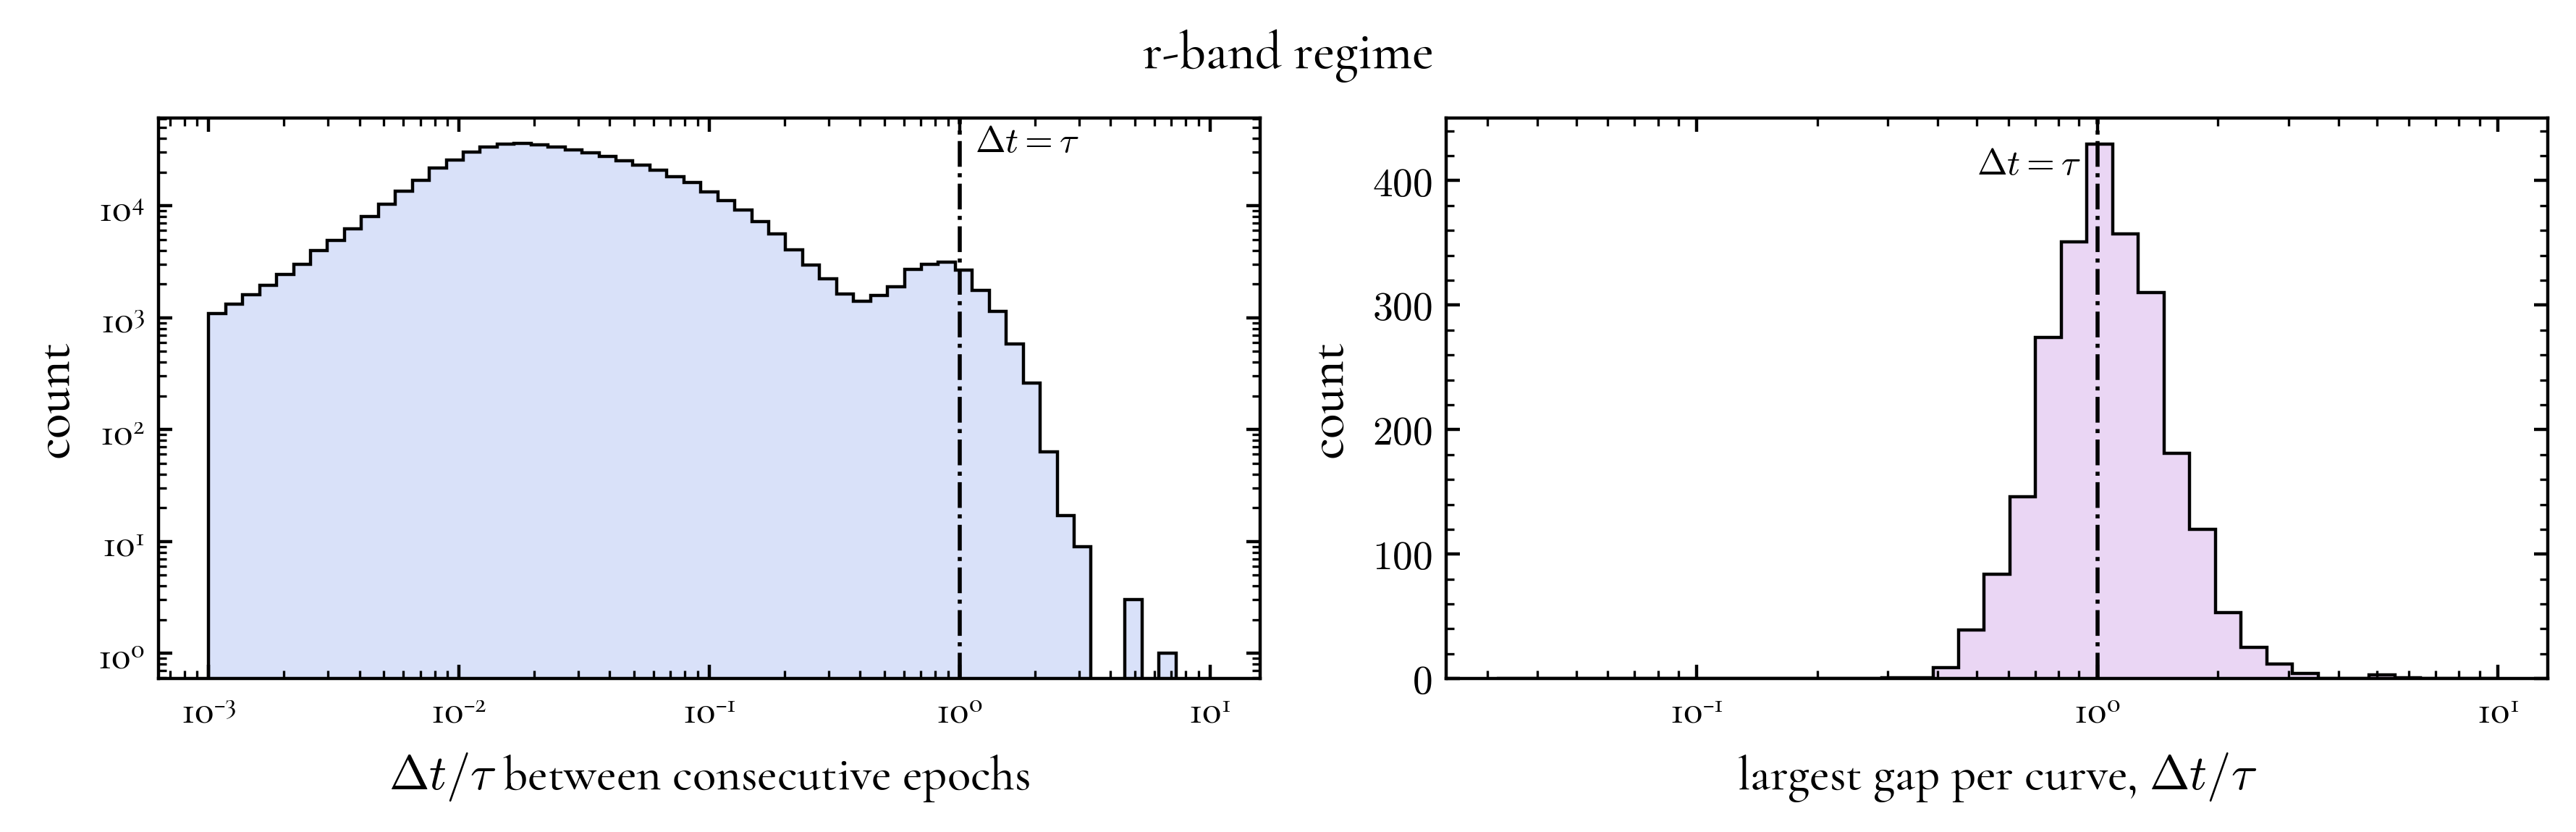

[r] spacings: median 0.023 tau, 99th 0.99 tau
[r] largest gap/curve: [0.59 1.05 1.88] tau  (5/50/95)
[r] spacings above 1 tau: 1.0%   curves whose largest gap > 1 tau: 56%
r: 2400+600 curves saved


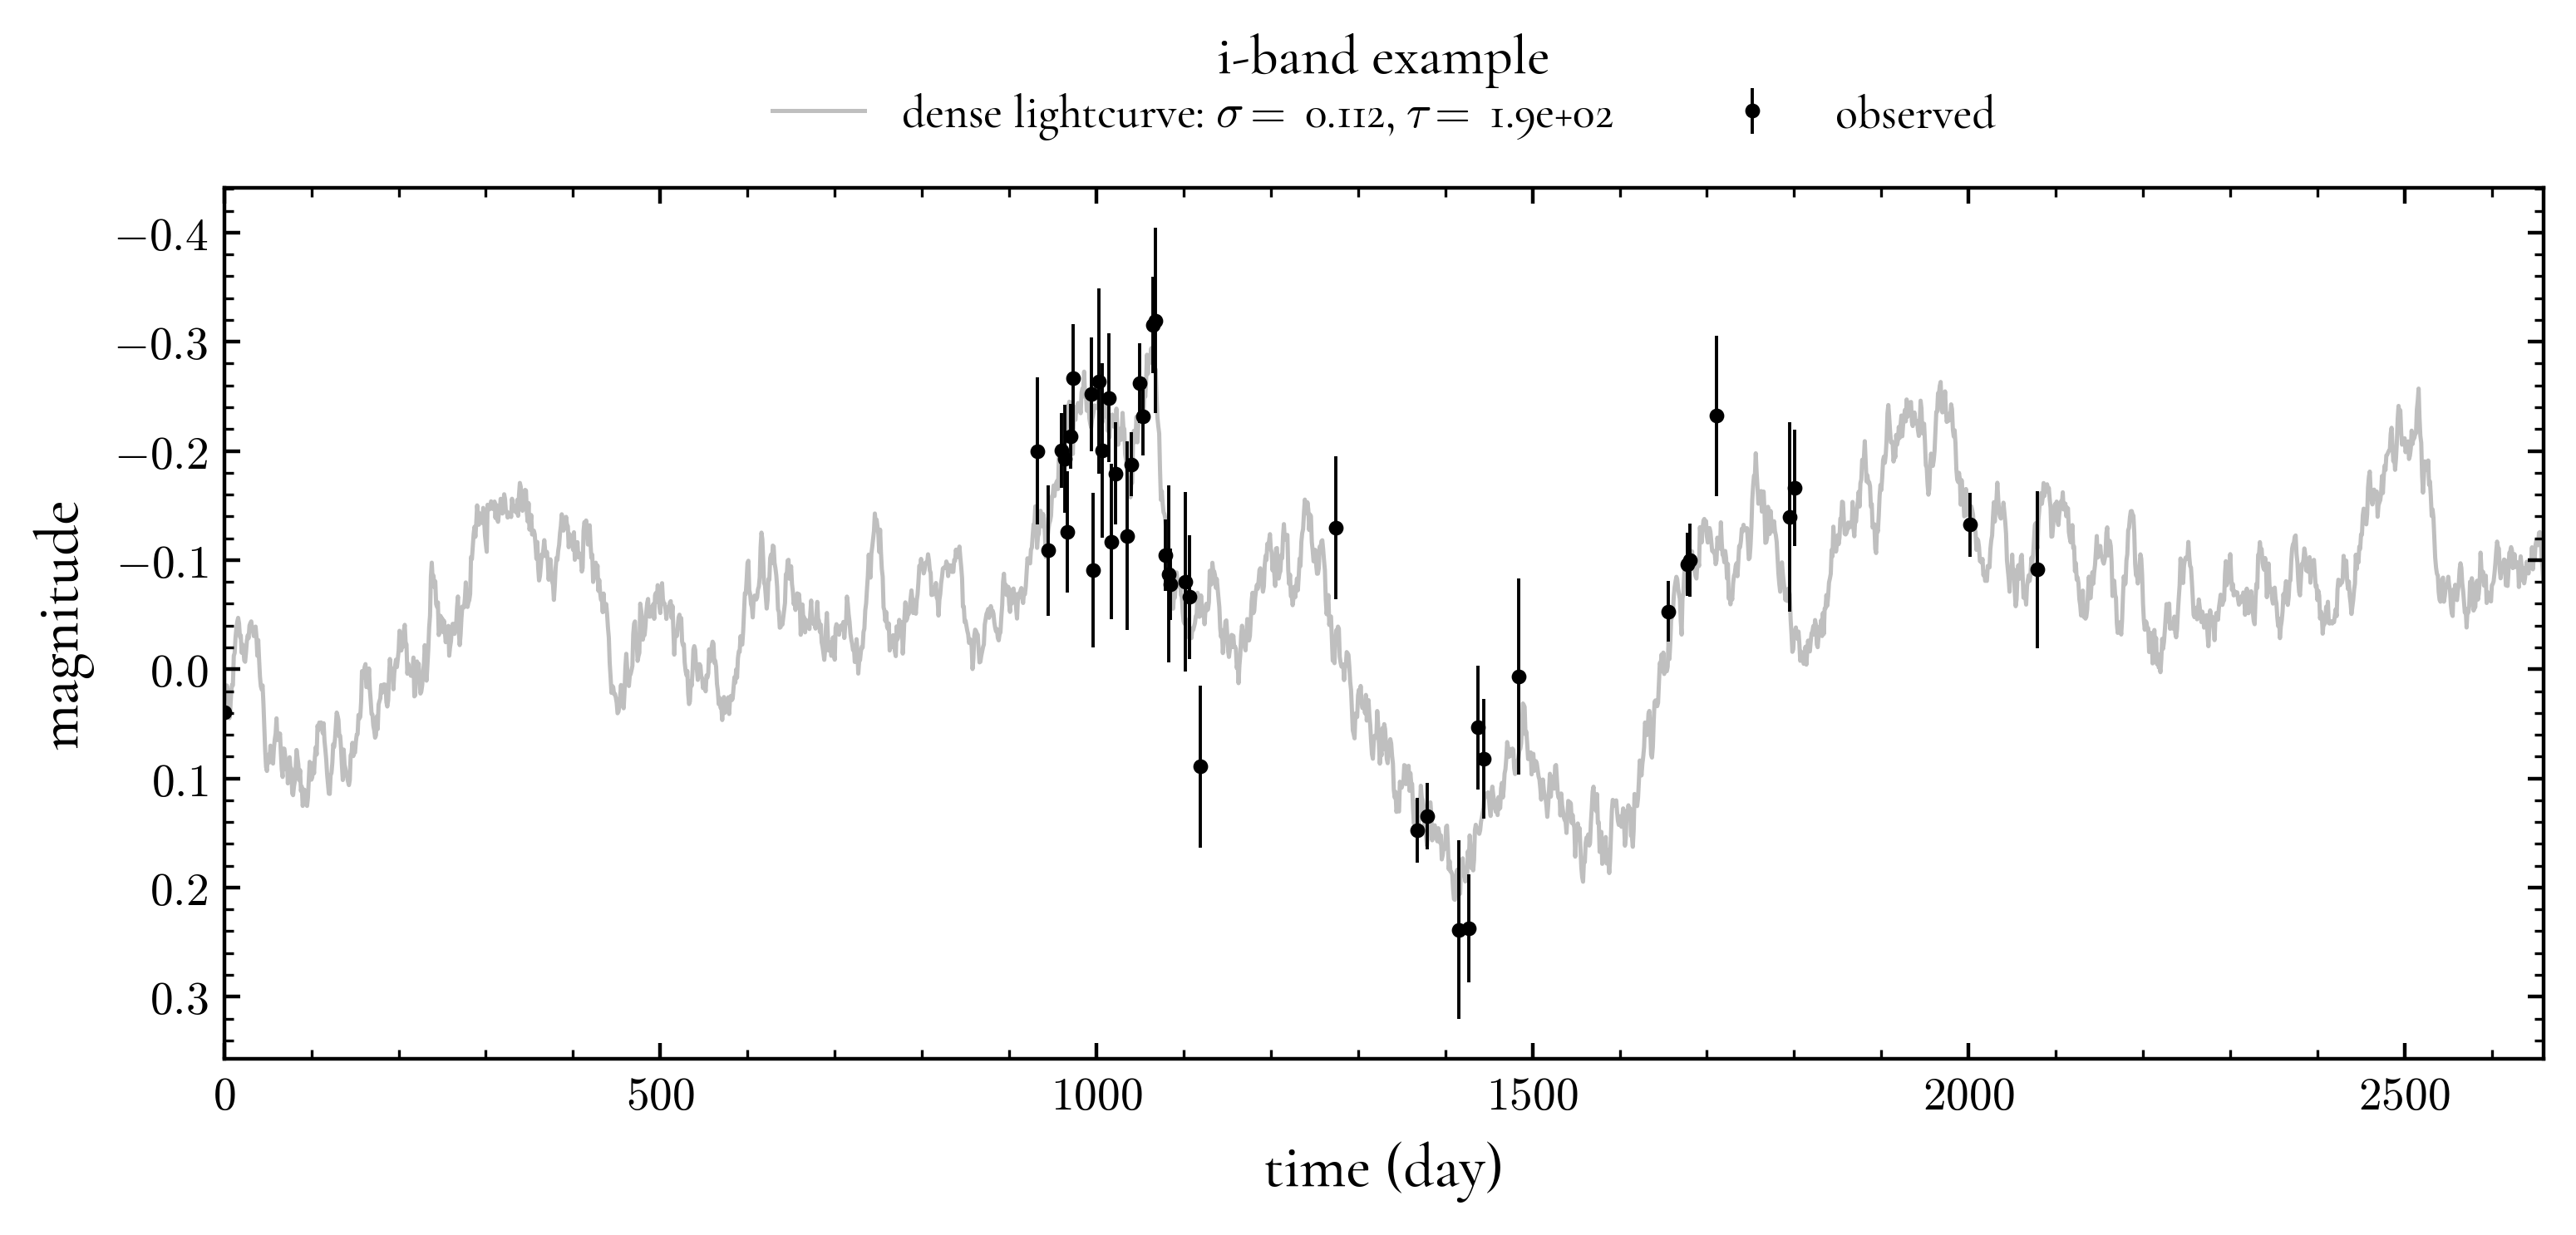

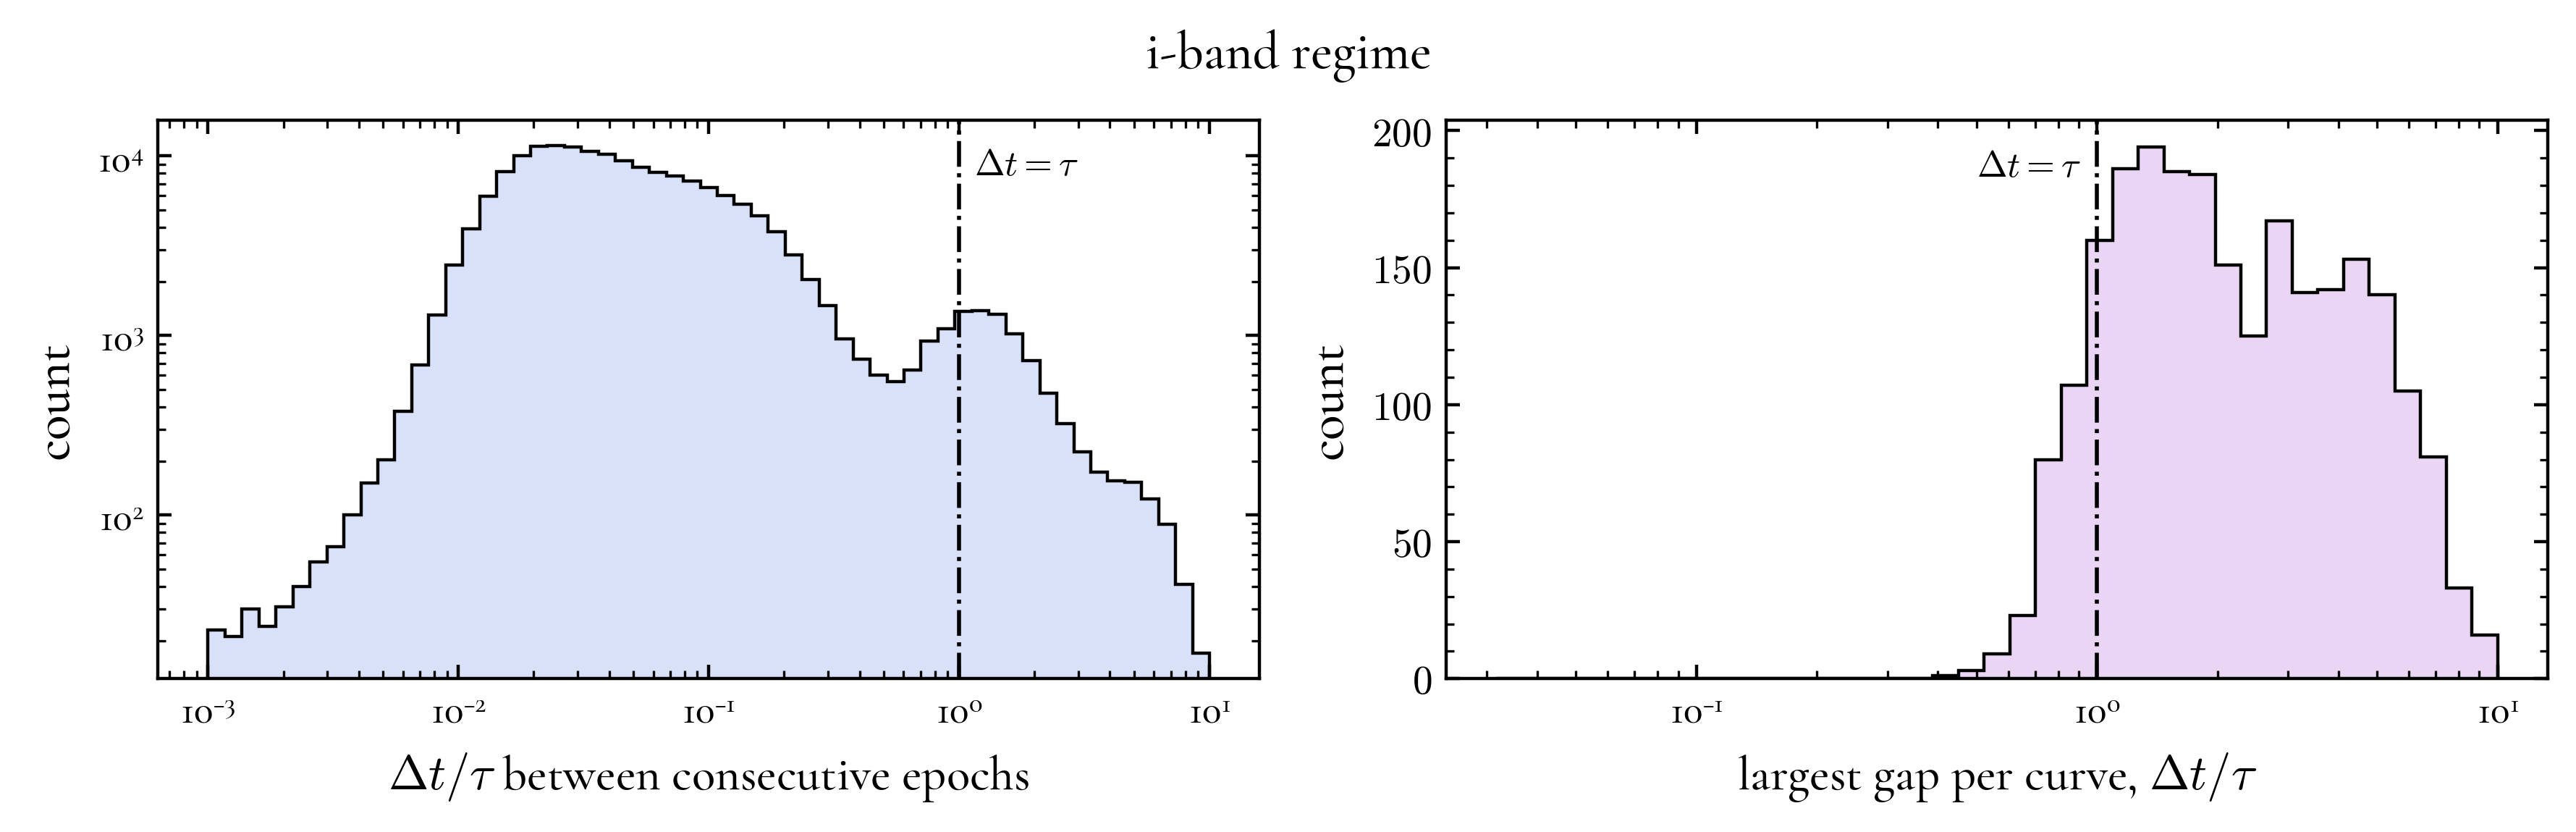

[i] spacings: median 0.042 tau, 99th 2.12 tau
[i] largest gap/curve: [0.82 2.1  6.71] tau  (5/50/95)
[i] spacings above 1 tau: 4.1%   curves whose largest gap > 1 tau: 89%
i: 2400+600 curves saved


In [ ]:
for band in ["g", "r", "i"]:
    train_c, val_c = make_band_dataset(band, ZTF)
    plotLC(train_c[0])                    
    plt.title(f"{band}-band example", pad = 25)
    plt.savefig(f"/Users/anacecilialr/GitHub/MASS/MASS-Thesis/assets/5_figures/ZTF_simulated_lc_{band}.pdf")
    plt.show()
    plot_regime(train_c, band)
    saveDataset(train_c, f"{DATA}/train_{band}.npz")
    saveDataset(val_c,   f"{DATA}/val_{band}.npz")
    print(f"{band}: {len(train_c)}+{len(val_c)} curves saved")

The i band is way more sparce than g or r, with gaps that are highly uncorrelated. g is the noisiest band which adds another regime of difficulty. 